# Partie C — Analyse exploratoire et relations entre variables

Objectif : Comprendre la structure des données, identifier les relations clés
entre variables et les comportements différenciants par rapport à la cible Response.

In [1]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

df = pd.read_csv('../data/processed/df_clean.csv')
print(f"Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes")

Dataset chargé : 2212 lignes x 32 colonnes


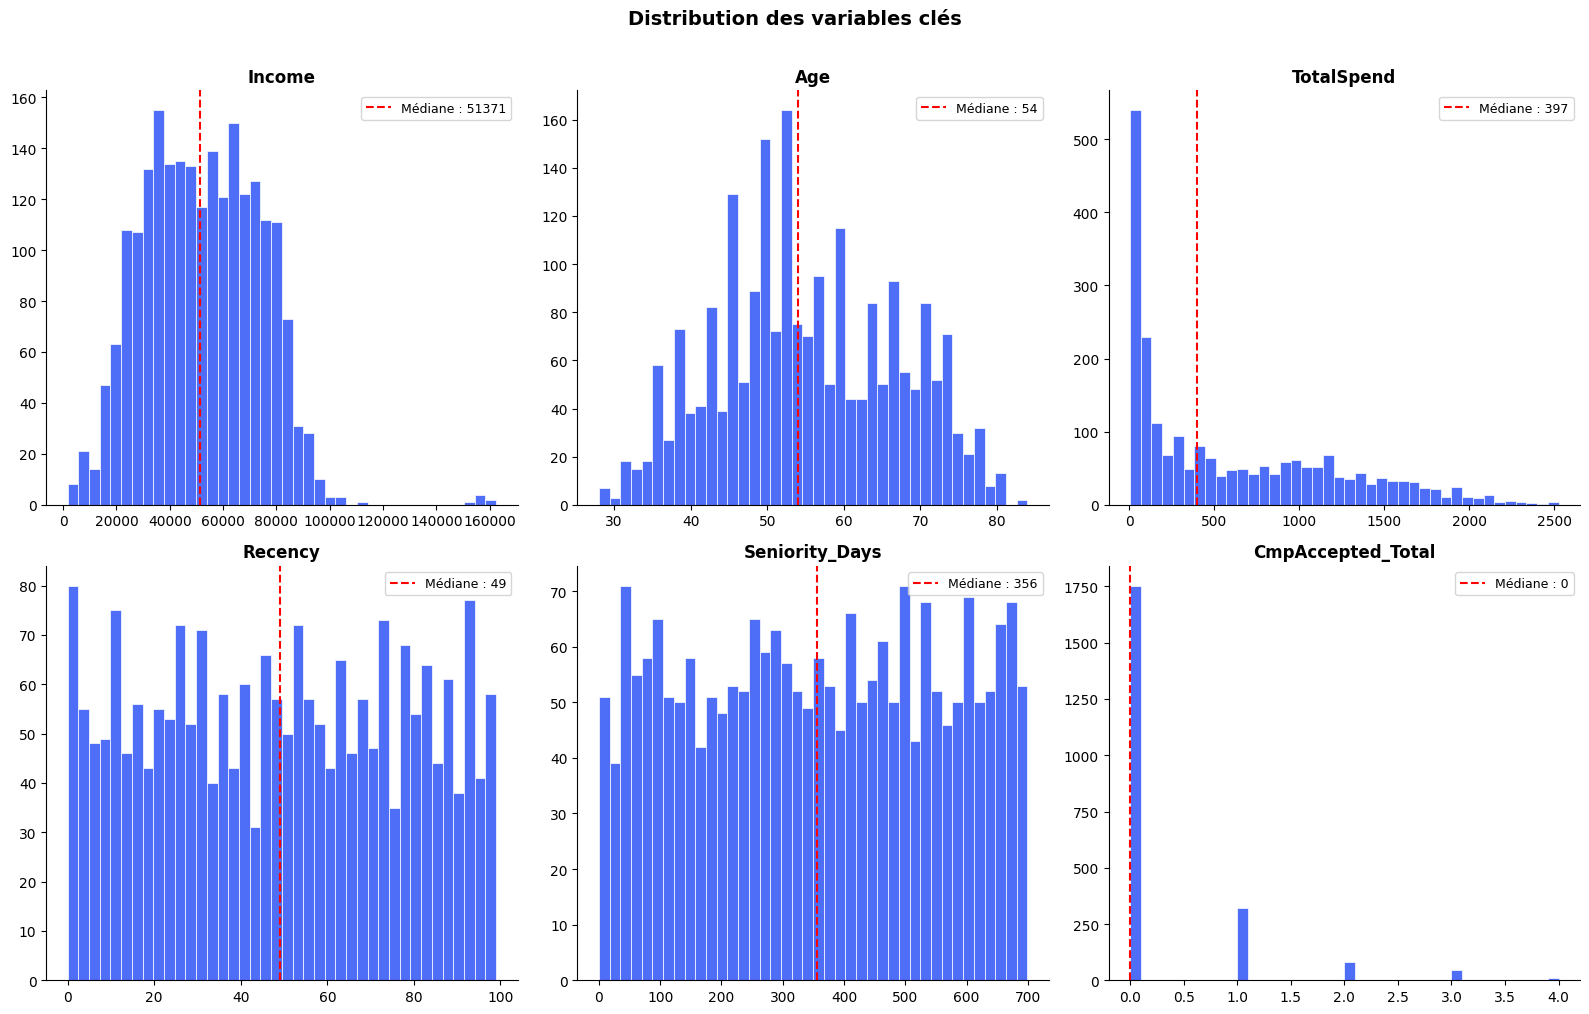

Figure sauvegardée


In [2]:
# ── 1. DISTRIBUTION DES VARIABLES CLES ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

vars_to_plot = ['Income', 'Age', 'TotalSpend',
                'Recency', 'Seniority_Days', 'CmpAccepted_Total']

for i, var in enumerate(vars_to_plot):
    axes[i].hist(df[var], bins=40, color='#4f6ef7', edgecolor='white', linewidth=0.5)
    axes[i].axvline(df[var].median(), color='red', linestyle='--',
                    linewidth=1.5, label=f'Médiane : {df[var].median():.0f}')
    axes[i].set_title(var, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=9)
    sns.despine(ax=axes[i])

plt.suptitle('Distribution des variables clés', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/C_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée")

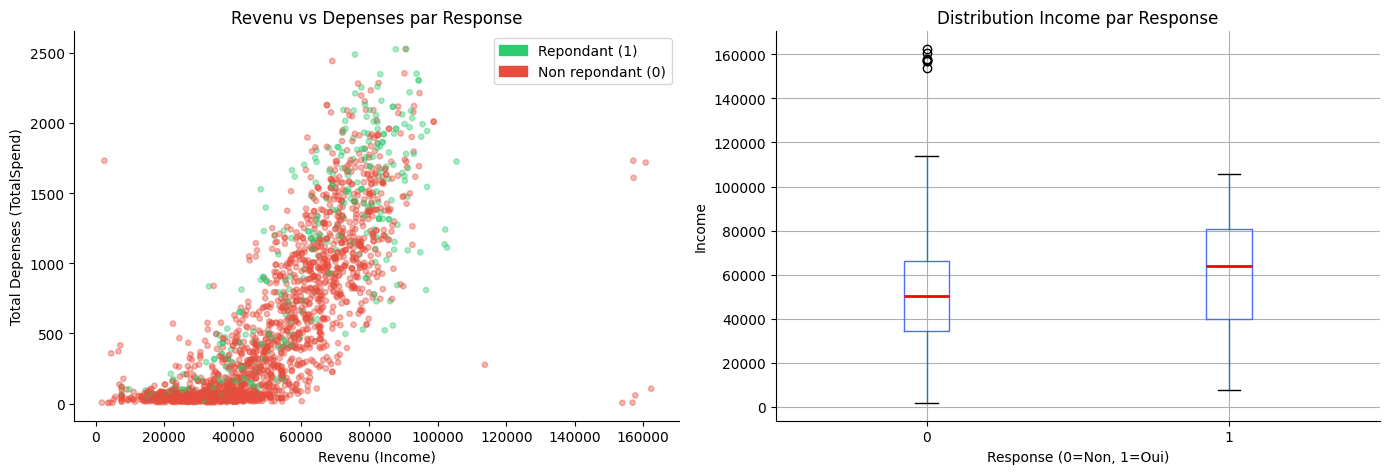

Correlation Income / TotalSpend : 0.793


In [3]:
# ── 2. REVENU vs DEPENSES ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Income vs TotalSpend coloré par Response
colors = df['Response'].map({0: '#e74c3c', 1: '#2ecc71'})
axes[0].scatter(df['Income'], df['TotalSpend'], c=colors, alpha=0.4, s=15)
axes[0].set_xlabel('Revenu (Income)')
axes[0].set_ylabel('Total Depenses (TotalSpend)')
axes[0].set_title('Revenu vs Depenses par Response')
from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Repondant (1)'),
          Patch(color='#e74c3c', label='Non repondant (0)')]
axes[0].legend(handles=legend)
sns.despine(ax=axes[0])

# Boxplot Income par Response
df.boxplot(column='Income', by='Response', ax=axes[1],
           boxprops=dict(color='#4f6ef7'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Distribution Income par Response')
axes[1].set_xlabel('Response (0=Non, 1=Oui)')
axes[1].set_ylabel('Income')
plt.suptitle('')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('../reports/figures/C_income_vs_spend.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df['Income'].corr(df['TotalSpend'])
print(f"Correlation Income / TotalSpend : {corr:.3f}")

In [4]:
# ── 3. COMPORTEMENT MOYEN : REPONDANTS vs NON REPONDANTS ──
vars_behaviour = ['Income', 'TotalSpend', 'Age', 'Recency',
                  'CmpAccepted_Total', 'NumWebPurchases',
                  'NumStorePurchases', 'TotalChildren']

summary = df.groupby('Response')[vars_behaviour].mean().T
summary.columns = ['Non repondant (0)', 'Repondant (1)']
summary['Ecart %'] = ((summary['Repondant (1)'] - summary['Non repondant (0)'])
                      / summary['Non repondant (0)'] * 100).round(1)
summary = summary.round(2)

print("=" * 60)
print("COMPORTEMENT MOYEN : REPONDANTS vs NON REPONDANTS")
print("=" * 60)
print(summary.to_string())

COMPORTEMENT MOYEN : REPONDANTS vs NON REPONDANTS
                   Non repondant (0)  Repondant (1)  Ecart %
Income                      50496.58       60209.68    19.20
TotalSpend                    540.21         985.66    82.50
Age                            55.19          54.50    -1.20
Recency                        51.46          35.26   -31.50
CmpAccepted_Total               0.18           0.99   460.90
NumWebPurchases                 3.91           5.07    29.60
NumStorePurchases               5.76           6.08     5.60
TotalChildren                   1.00           0.65   -35.20


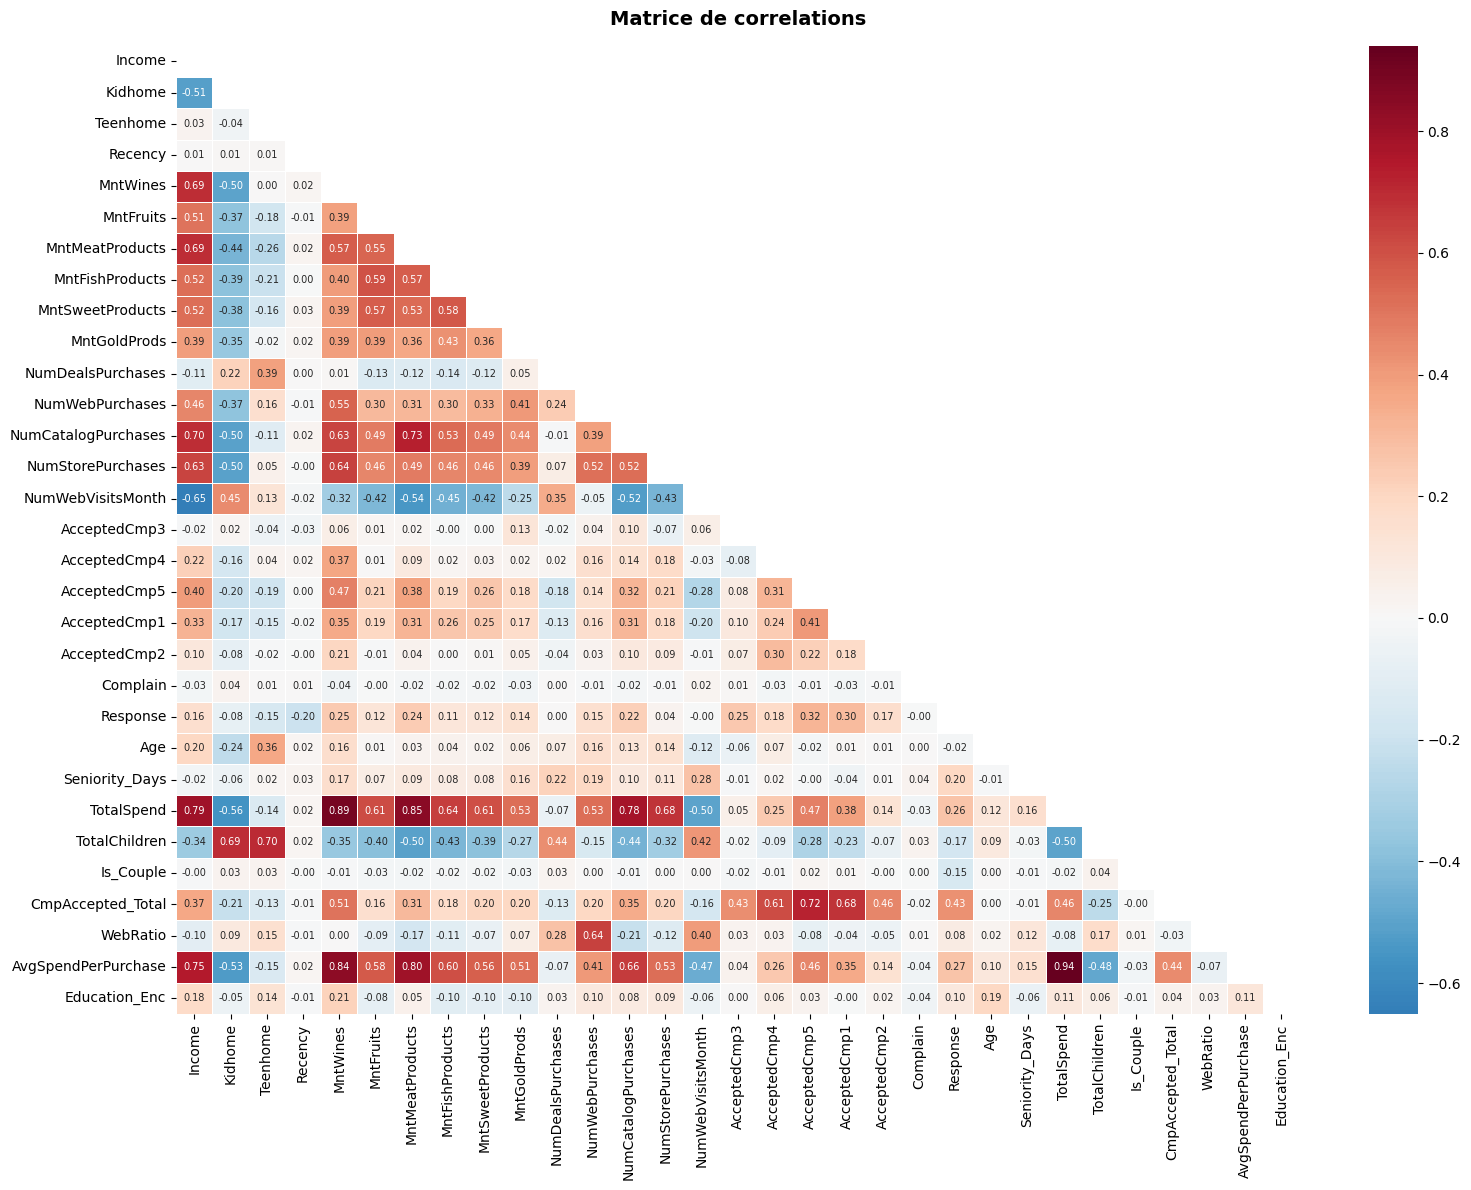

Figure sauvegardée


In [5]:
# ── 4. MATRICE DE CORRELATIONS ────────────────────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Matrice de correlations', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/C_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée")

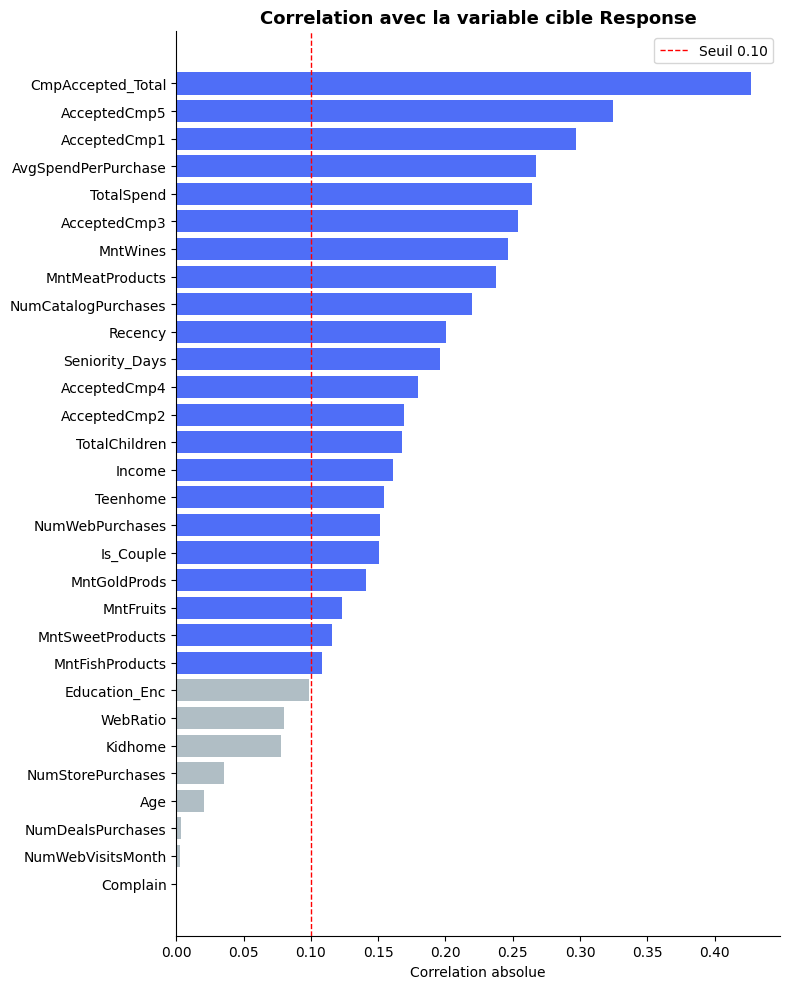


Top 10 variables les plus correlees a Response :
CmpAccepted_Total     0.43
AcceptedCmp5          0.32
AcceptedCmp1          0.30
AvgSpendPerPurchase   0.27
TotalSpend            0.26
AcceptedCmp3          0.25
MntWines              0.25
MntMeatProducts       0.24
NumCatalogPurchases   0.22
Recency               0.20


In [6]:
# ── 5. VARIABLES LES PLUS LIEES A RESPONSE ───────────────
corr_target = df[numeric_cols].corr()['Response'].drop('Response')
corr_target = corr_target.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
bars = ax.barh(corr_target.index, corr_target.values,
               color=['#4f6ef7' if v > 0.1 else '#b0bec5' for v in corr_target.values])
ax.axvline(0.1, color='red', linestyle='--', linewidth=1, label='Seuil 0.10')
ax.set_title('Correlation avec la variable cible Response', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation absolue')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('../reports/figures/C_correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 variables les plus correlees a Response :")
print(corr_target.sort_values(ascending=False).head(10).to_string())

In [7]:
# ── 6. SYNTHESE PARTIE C ─────────────────────────────────
print("=" * 60)
print("SYNTHESE — ANALYSE EXPLORATOIRE")
print("=" * 60)

insights = [
    "Correlation Income/TotalSpend : 0.793 -> revenu = driver principal des depenses",
    "Repondants depensent 82% de plus que non-repondants (985 vs 540)",
    "Repondants ont un revenu superieur de 19% (60 209 vs 50 496)",
    "Recency plus faible chez repondants : -31% -> ils sont plus engages",
    "CmpAccepted_Total : correlation 0.43 -> variable la plus predictive",
    "TotalChildren negatif : moins d'enfants = plus de budget disponible",
    "Variables peu informatives : Age, NumDealsPurchases, Complain, NumWebVisitsMonth",
]

print("\nInsights principaux :")
for i in insights:
    print(f"   - {i}")

print("\nVariables retenues pour la segmentation et la modelisation :")
vars_selected = ['Income', 'TotalSpend', 'Recency', 'CmpAccepted_Total',
                 'AvgSpendPerPurchase', 'MntWines', 'MntMeatProducts',
                 'NumCatalogPurchases', 'TotalChildren', 'Age', 'Seniority_Days']
for v in vars_selected:
    print(f"   - {v}")

print("\nNEXT : Partie D — Segmentation client par clustering")

SYNTHESE — ANALYSE EXPLORATOIRE

Insights principaux :
   - Correlation Income/TotalSpend : 0.793 -> revenu = driver principal des depenses
   - Repondants depensent 82% de plus que non-repondants (985 vs 540)
   - Repondants ont un revenu superieur de 19% (60 209 vs 50 496)
   - Recency plus faible chez repondants : -31% -> ils sont plus engages
   - CmpAccepted_Total : correlation 0.43 -> variable la plus predictive
   - TotalChildren negatif : moins d'enfants = plus de budget disponible
   - Variables peu informatives : Age, NumDealsPurchases, Complain, NumWebVisitsMonth

Variables retenues pour la segmentation et la modelisation :
   - Income
   - TotalSpend
   - Recency
   - CmpAccepted_Total
   - AvgSpendPerPurchase
   - MntWines
   - MntMeatProducts
   - NumCatalogPurchases
   - TotalChildren
   - Age
   - Seniority_Days

NEXT : Partie D — Segmentation client par clustering
